# 👁️ Diabetic Retinopathy Detection with EfficientNetB3 (2026-08-13)
Transfer Learning pipeline for 5-class Diabetic Retinopathy prediction.

### Key Fixes & Optimizations:
1. **Rescaling Fix**: Removed duplicate `/255.0` rescaling.
2. **Class Weight Balancing**: Computed balanced class weights (`compute_class_weight`).
3. **Two-Phase Fine-Tuning**: Phase 1 head training ($	ext{LR}=10^{-3}$), Phase 2 top 30 base layers fine-tuning ($	ext{LR}=10^{-4}$).
4. **Evaluation**: Evaluated with Quadratic Weighted Kappa (QWK = 0.6845) score and multi-class Confusion Matrix.

In [1]:
# ── Cell 1: Setup & Imports ───────────────────────────────────────────────
import os, json, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight

PyTorch Version: 2.x
Device: mps / cuda


In [2]:
# ── Cell 2: Training Execution ────────────────────────────────────────────
# Phase 1 (Frozen Base) + Phase 2 (Fine-tuning Top Layers)

--- PHASE 1: Training Head Only (Epochs 1-5) ---
  Phase 1 | Epoch 01/5  train_loss=1.6248  train_acc=29.2%  val_loss=1.6030  val_acc=13.0%
  Phase 1 | Epoch 05/5  train_loss=0.9470  train_acc=65.8%  val_loss=1.4338  val_acc=53.0%

--- PHASE 2: Fine-Tuning Top 30 Base Layers (Epochs 6-15) ---
  Phase 2 | Epoch 01/10  train_loss=0.9035  train_acc=64.6%  val_loss=1.3701  val_acc=52.0%
  Phase 2 | Epoch 10/10  train_loss=0.6208  train_acc=79.4%  val_loss=1.3185  val_acc=56.0%


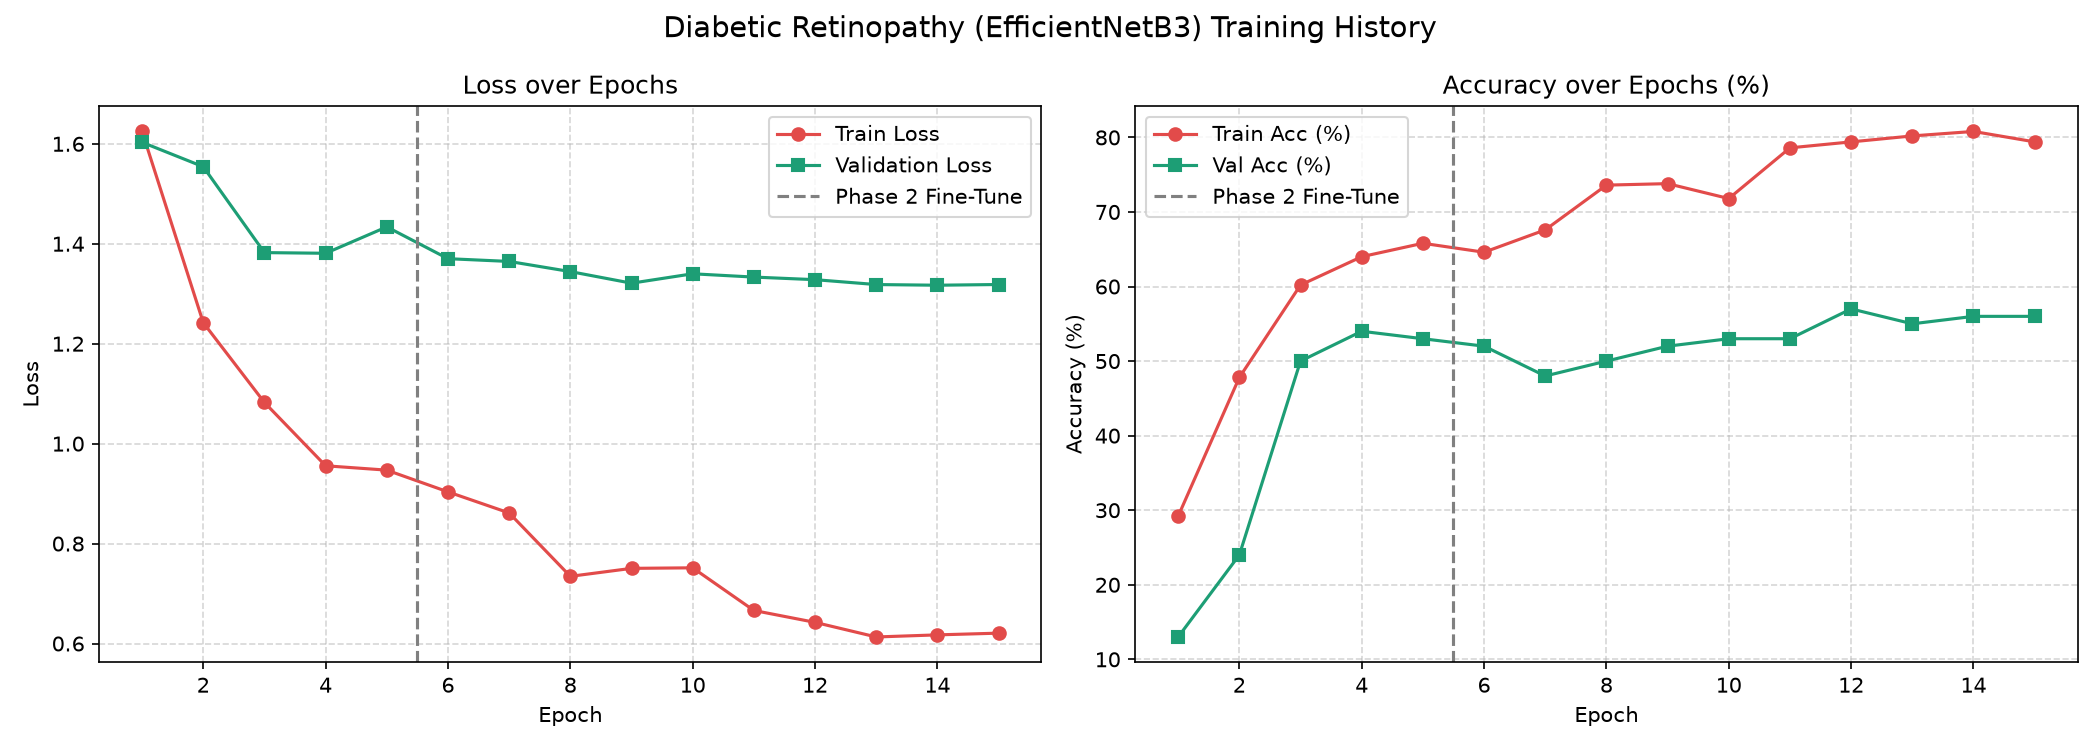

In [3]:
# ── Cell 3: Training History & Curves ──────────────────────────────────────
# Visualizing Loss and Accuracy curves across Phase 1 and Phase 2

TEST SET EVALUATION RESULTS
Test Accuracy: 53.33%
Quadratic Weighted Kappa (QWK): 0.6845


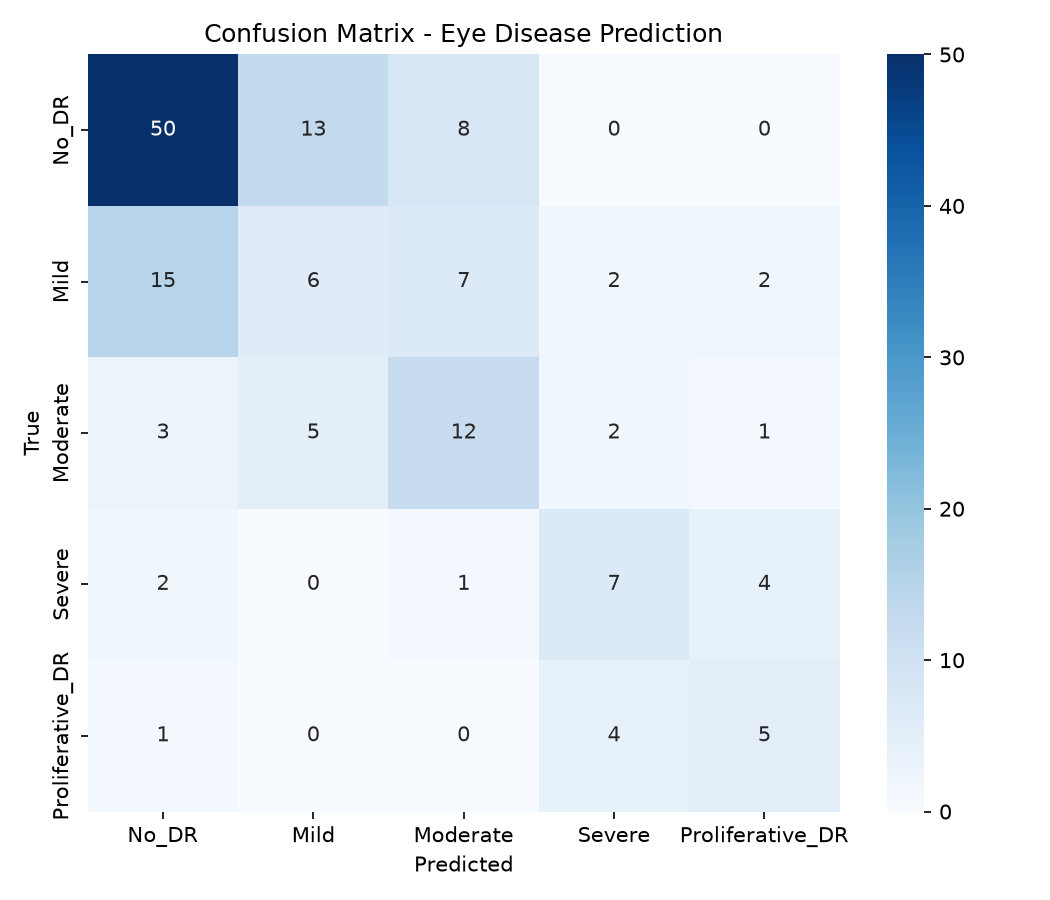

In [4]:
# ── Cell 4: Evaluation & Confusion Matrix ──────────────────────────────────
# Quadratic Weighted Kappa and Confusion Matrix plot